# Library Energy Consumption Forecasting with XGBoost

**Task:** Predict library power consumption 24 hours ahead (144 steps at 10-minute resolution)
**Model:** XGBoost, benchmarked against a naive persistence baseline and Linear Regression
**Data:** `library_cleaned_master.csv` — 10-minute readings, February 2014 to November 2017
**Split strategy:** 70% train / 30% test, chronological, no separate validation set — hyperparameter
tuning uses `TimeSeriesSplit` cross-validation inside the training set instead.

This notebook follows the exact same training setting as the LightGBM and Extra Trees notebooks on
this dataset — same features, same target, same chronological split, same baselines, same
`TimeSeriesSplit`/`RandomizedSearchCV` tuning scheme — so the final metrics are directly comparable
across all three models. Only the model itself and its model-specific hyperparameter grid change.

## 1. Imports

Same imports as the LightGBM notebook, except `lightgbm`/`LGBMRegressor` is replaced with
`xgboost`/`XGBRegressor`. `np.random.seed(42)` plus `random_state=42` everywhere later keep results
reproducible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

np.random.seed(42)                      # global seed for reproducibility
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")

# ── TensorBoard setup ──────────────────────────────────────────────────────
import sys, os
if '..' not in sys.path: sys.path.insert(0, os.path.abspath('..'))
if '.' not in sys.path: sys.path.insert(0, os.path.abspath('.'))
from utils.tb_logger import SklearnTBLogger

tb_log_root = '../runs' if os.path.basename(os.getcwd()) == 'notebooks' else 'runs'
tb = SklearnTBLogger(model_name='XGBoost', log_root=tb_log_root)


## 2. Load and Inspect Data

Identical to the LightGBM notebook: read the CSV, parse `timestamp` as a real datetime, and sort
chronologically. This is the same `library_cleaned_master.csv` — no re-cleaning happens here.

In [2]:
df = pd.read_csv("library_cleaned_master.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])          # parse timestamp string -> datetime
df = df.sort_values("timestamp").reset_index(drop=True)    # enforce chronological order

print("Shape:", df.shape)
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
print()
print("Missing values per column:")
print(df.isnull().sum())

Shape: (118776, 7)
Date range: 2014-02-16 00:20:00+05:30 to 2017-11-03 23:50:00+05:30

Missing values per column:
timestamp          0
power              0
current            0
voltage            0
frequency          0
power_factor       0
occupancy_count    0
dtype: int64


In [3]:
df.head()

,timestamp,power,current,voltage,frequency,power_factor,occupancy_count
0,2014-02-16 00:20:00+05:30,6271.9930,8.991743,245.25345,50.227917,0.948552,4.0
1,2014-02-16 00:30:00+05:30,6266.4854,8.972734,245.40556,50.193413,0.949093,5.0
2,2014-02-16 00:40:00+05:30,6251.4180,8.953675,245.16708,50.148920,0.949744,5.0
3,2014-02-16 00:50:00+05:30,6345.1910,9.143141,243.07417,50.124634,0.951980,5.0
4,2014-02-16 01:00:00+05:30,6432.1733,9.251285,243.14775,50.100616,0.953440,5.0


## 3. Why Electrical Features Are Excluded

Same reasoning as the LightGBM and Extra Trees notebooks: `current`, `voltage`, `frequency`, and
`power_factor` are left out of the model inputs. `power` correlates with `current` at r ≈ 0.99
(near-restatement of the target), `current` was partially reconstructed from `power` during
cleaning (leakage risk), and none of these instantaneous readings would be available at prediction
time for a 24-hour-ahead forecast anyway.

## 4. Feature Engineering

Reused verbatim from the LightGBM notebook — calendar features, gap-aware lags, then the target,
then dropping incomplete rows. Keeping this identical is what makes the three-way model comparison
fair: every model sees exactly the same rows and columns.

### 4.1 Calendar features

In [4]:
df["hour"] = df["timestamp"].dt.hour                 # hour of day, 0-23
df["dayofweek"] = df["timestamp"].dt.dayofweek       # day of week, 0=Monday ... 6=Sunday
df["month"] = df["timestamp"].dt.month               # month, 1-12
df["weekend"] = (df["dayofweek"] >= 5).astype(int)    # 1 if Saturday/Sunday, else 0

### 4.2 Lag features (gap-aware)

This dataset has 1,124 gaps larger than 10 minutes. A plain `shift(144)` would sometimes pull a
value from days before a gap and mislabel it "yesterday." Each lag here takes the naive shift, then
checks the rolling **maximum** of `time_diff` over the same window — if a gap sits inside the
window, the value is forced to `NaN` instead of being silently wrong.

`power_lag_144` = same time yesterday. `power_lag_1008` = same time last week.

In [5]:
df["time_diff"] = df["timestamp"].diff().dt.total_seconds() / 60   # minutes since previous row

for lag in [144, 1008]:
    naive_shift = df["power"].shift(lag)                                        # plain lag
    max_gap_in_window = df["time_diff"].rolling(window=lag, min_periods=1).max()  # worst gap in window
    gap_present = max_gap_in_window > 10                                        # >10 min = real gap
    df[f"power_lag_{lag}"] = naive_shift.where(~gap_present, np.nan)             # NaN out unsafe lags

### 4.3 Target variable

`target` is `power` shifted 144 rows backward in time — the reading 24 hours into the future
relative to each row.

In [6]:
df["target"] = df["power"].shift(-144)   # power 24 hours into the future

### 4.4 Drop incomplete rows

Removes rows with any `NaN` — from insufficient history at the start, from gap-aware lag
invalidation, and from the undefined target at the end of the series.

In [7]:
rows_before = len(df)
df_clean = df.dropna().reset_index(drop=True)
rows_after = len(df_clean)

print(f"Rows before dropna: {rows_before:,}")
print(f"Rows after dropna:  {rows_after:,}")
print(f"Rows dropped:       {rows_before - rows_after:,}  ({(rows_before-rows_after)/rows_before:.1%})")

Rows before dropna: 118,776
Rows after dropna:  41,248
Rows dropped:       77,528  (65.3%)


## 5. Feature List and Train/Test Split

Same `FEATURES`, `TARGET`, and 70/30 chronological split as the LightGBM notebook — no shuffling,
since shuffling a time series before splitting would leak future information into training.

In [8]:
FEATURES = [
    "power",              # current power reading at time t (lag_0)
    "occupancy_count",    # number of people in building
    "hour", "dayofweek", "month", "weekend",
    "power_lag_144",      # same time yesterday
    "power_lag_1008",     # same time last week
]
TARGET = "target"

n = len(df_clean)
train_end = int(n * 0.70)

train_df = df_clean.iloc[:train_end]
test_df  = df_clean.iloc[train_end:]

X_train = train_df[FEATURES]; y_train = train_df[TARGET]
X_test  = test_df[FEATURES];  y_test  = test_df[TARGET]

print(f"Train: {len(train_df):,} rows  |  {train_df['timestamp'].min()}  to  {train_df['timestamp'].max()}")
print(f"Test:  {len(test_df):,} rows  |  {test_df['timestamp'].min()}  to  {test_df['timestamp'].max()}")

Train: 28,873 rows  |  2014-02-26 10:30:00+05:30  to  2016-11-20 12:50:00+05:30
Test:  12,375 rows  |  2016-11-20 13:00:00+05:30  to  2017-11-02 23:50:00+05:30


## 6. Baseline Models

Identical baselines to the LightGBM and Extra Trees notebooks, recomputed here so this notebook is
fully self-contained. Numbers should match those notebooks exactly, since the data, features, and
split are all the same.

### 6.1 Naive Persistence

In [9]:
y_pred_persist = X_test["power"].values     # predict power(t+24h) = power(t)

mae_persist = mean_absolute_error(y_test, y_pred_persist)
rmse_persist = np.sqrt(mean_squared_error(y_test, y_pred_persist))
r2_persist = r2_score(y_test, y_pred_persist)

print("Naive Persistence Baseline")
print(f"  MAE:  {mae_persist:>8.0f}")
print(f"  RMSE: {rmse_persist:>8.0f}")
print(f"  R2:   {r2_persist:>8.4f}")

Naive Persistence Baseline
  MAE:      3580
  RMSE:     6225
  R2:     0.3866


### 6.2 Linear Regression

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Baseline")
print(f"  MAE:  {mae_lr:>8.0f}")
print(f"  RMSE: {rmse_lr:>8.0f}")
print(f"  R2:   {r2_lr:>8.4f}")

Linear Regression Baseline
  MAE:      3989
  RMSE:     5743
  R2:     0.4779


## 8. Hyperparameter Tuning

`RandomizedSearchCV` samples `n_iter=20` random combinations, scoring on R² over
`TimeSeriesSplit(n_splits=3, gap=144)` — identical search protocol and random seed to the LightGBM
notebook. Only the grid itself changes, since it needs to name parameters XGBoost actually has:
`n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`,
`min_child_weight` (XGBoost's analogue of LightGBM's `min_child_samples`), `reg_alpha`,
`reg_lambda`, and `gamma` (a minimum-loss-reduction threshold before a split is allowed — an extra
regularization lever specific to XGBoost's split-finding). `n_jobs=1` on the search loop keeps the
search itself sequential; `tree_method="hist"` is XGBoost's fast, LightGBM-style histogram
algorithm.

In [11]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8],
    "min_child_weight": [5, 10, 15],
    "reg_alpha": [0.5, 1.5, 3.0],
    "reg_lambda": [1.0, 3.0, 5.0],
    "gamma": [0, 0.1, 0.3],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, tree_method="hist", verbosity=0),
    param_grid,
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=3, gap=144),
    scoring="r2",
    n_jobs=1,
    random_state=42,
    verbose=0,
)

search.fit(X_train, y_train)

print("Best parameters found:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV R2 (3-fold, tuning only): {search.best_score_:.4f}")

# ── Log hyperparameter trials to TensorBoard ────────────────────────────────
results = search.cv_results_
for i in range(len(results['params'])):
    tb.log_hyperparam_trial(
        trial=i,
        params=results['params'][i],
        r2=results['mean_test_score'][i]
    )


Best parameters found:
  subsample: 0.7
  reg_lambda: 3.0
  reg_alpha: 0.5
  n_estimators: 300
  min_child_weight: 5
  max_depth: 5
  learning_rate: 0.01
  gamma: 0.1
  colsample_bytree: 0.7

Best CV R2 (3-fold, tuning only): 0.6060


## 9. TimeSeriesSplit Cross-Validation (5 Folds)

Run only on `X_train`/`y_train` — the test set is never touched here. Same
`TimeSeriesSplit(n_splits=5, gap=144)` as the LightGBM notebook. This report uses the
hyperparameters found in Section 8, and the **mean R² across folds** is the key summary metric
used to sanity-check the tuned model before ever touching the test set.

In [12]:
tscv = TimeSeriesSplit(n_splits=5, gap=144)
fold_metrics = []

best_params = search.best_params_

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    X_tr_fold, X_val_fold = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = XGBRegressor(**best_params, random_state=42, tree_method="hist", verbosity=0)
    model.fit(X_tr_fold, y_tr_fold)
    preds = model.predict(X_val_fold)

    mae = mean_absolute_error(y_val_fold, preds)
    rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
    r2 = r2_score(y_val_fold, preds)
    fold_metrics.append((mae, rmse, r2))
    tb.log_cv_fold(fold=fold, y_val=y_val_fold, y_pred=preds)

    print(f"Fold {fold} | MAE: {mae:>6.0f}  RMSE: {rmse:>6.0f}  R2: {r2:.4f}")

fold_arr = np.array(fold_metrics)
mean_mae, mean_rmse, mean_r2 = fold_arr.mean(axis=0)
std_mae, std_rmse, std_r2 = fold_arr.std(axis=0)

print("-" * 47)
print(f"Mean   | MAE: {mean_mae:>6.0f}  RMSE: {mean_rmse:>6.0f}  R2: {mean_r2:.4f}")
print(f"Std    | MAE: {std_mae:>6.0f}  RMSE: {std_rmse:>6.0f}  R2: {std_r2:.4f}")

Fold 1 | MAE:   5603  RMSE:   8492  R2: -0.0231
Fold 2 | MAE:   4276  RMSE:   5573  R2: 0.3693
Fold 3 | MAE:   2794  RMSE:   3971  R2: 0.5732
Fold 4 | MAE:   2475  RMSE:   3148  R2: 0.7442
Fold 5 | MAE:   2950  RMSE:   4224  R2: 0.6792
-----------------------------------------------
Mean   | MAE:   3620  RMSE:   5081  R2: 0.4685
Std    | MAE:   1167  RMSE:   1875  R2: 0.2767


## 10. Final Model Training

Trains on the full `X_train`/`y_train` using the best hyperparameters found in Section 8,
including a fixed `n_estimators` — there is no early stopping and no separate monitor-set
carve-out here, matching the LightGBM notebook's final, corrected approach. Tree count is chosen
the same way every other hyperparameter is: by `RandomizedSearchCV`'s
`TimeSeriesSplit(n_splits=3, gap=144)`, which averages performance across three different rolling
training/validation slices. Testing on the LightGBM notebook showed that a single held-out monitor
slice used for early stopping is a noisier, less representative stopping signal than this
cross-validated tree count, so the same choice is kept here for consistency and for the same
empirically-tested reason. `X_test`/`y_test` are never referenced in this cell.

In [13]:
best_params = search.best_params_
final_model = XGBRegressor(**best_params, random_state=42, tree_method="hist", verbosity=0)
final_model.fit(X_train, y_train)

train_preds = final_model.predict(X_train)
test_preds = final_model.predict(X_test)
y_pred_xgb = test_preds

print(f"Number of trees in final model: {final_model.n_estimators}")

# ── Log final train + test metrics to TensorBoard ──────────────────────────
tb.log_final(
    y_train=y_train,
    y_pred_train=train_preds,
    y_test=y_test,
    y_pred_test=test_preds,
    hparams=best_params
)


Number of trees in final model: 300


## 11. Final Evaluation

Predictions on `X_test` are computed here for the first and only time — the single, honest measure
of performance on genuinely unseen data. Compare this table's XGBoost row directly against the
LightGBM and Extra Trees rows, since every upstream step (features, target, split, tuning
protocol) is identical across all three notebooks.

In [14]:
mae_xgb = mean_absolute_error(y_test, test_preds)
rmse_xgb = np.sqrt(mean_squared_error(y_test, test_preds))
r2_xgb = r2_score(y_test, test_preds)

train_r2 = r2_score(y_train, train_preds)
train_mae = mean_absolute_error(y_train, train_preds)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))

print("=" * 52)
print(f"  {'Model':<22}{'MAE':>8}{'RMSE':>10}{'R2':>10}")
print("=" * 52)
print(f"  {'Naive Persistence':<22}{mae_persist:>8.0f}{rmse_persist:>10.0f}{r2_persist:>10.4f}")
print(f"  {'Linear Regression':<22}{mae_lr:>8.0f}{rmse_lr:>10.0f}{r2_lr:>10.4f}")
print(f"  {'XGBoost (Final)':<22}{mae_xgb:>8.0f}{rmse_xgb:>10.0f}{r2_xgb:>10.4f}")
print("=" * 52)

print(f"\nTrain R2: {train_r2:.4f}   Train MAE: {train_mae:.2f}   Train RMSE: {train_rmse:.2f}")
print(f"R2 gap (train - test): {train_r2 - r2_xgb:.4f}")

  Model                      MAE      RMSE        R2
  Naive Persistence         3580      6225    0.3866
  Linear Regression         3989      5743    0.4779
  XGBoost (Final)           3180      4405    0.6928

Train R2: 0.7925   Train MAE: 2206.63   Train RMSE: 3156.17
R2 gap (train - test): 0.0997


### 11.1 Train vs. Test — Overfitting Check

Same diagnostic as the Extra Trees notebook's Section 10.1: scoring the fitted model on both
`X_train` and `X_test` reveals whether it's learning transferable structure or partly memorizing
training rows, rather than just reporting a single test score.

- **Train ≈ Test** → the model generalizes; the tuned hyperparameters are doing their job.
- **Train ≫ Test** → overfitting — the model is partly memorizing training rows rather than
  learning patterns that transfer.
- **Both low** → underfitting — the model or features aren't capturing enough signal even on
  data it has already seen.

This is a read-only diagnostic — it doesn't change `final_model` or retrain anything, it just
reuses the `train_preds`/`test_preds` already computed above.

In [15]:
print("=" * 52)
print(f"  {'Set':<22}{'MAE':>8}{'RMSE':>10}{'R2':>10}")
print("=" * 52)
print(f"  {'Train':<22}{train_mae:>8.0f}{train_rmse:>10.0f}{train_r2:>10.4f}")
print(f"  {'Test':<22}{mae_xgb:>8.0f}{rmse_xgb:>10.0f}{r2_xgb:>10.4f}")
print("=" * 52)

r2_gap = train_r2 - r2_xgb
print(f"\nR2 gap (train - test): {r2_gap:.4f}")
if r2_gap > 0.15:
    print("-> Large gap: model is overfitting the training set.")
elif train_r2 < 0.5:
    print("-> Both scores are low: model may be underfitting.")
else:
    print("-> Gap is modest: model is generalizing reasonably well.")

  Set                        MAE      RMSE        R2
  Train                     2207      3156    0.7925
  Test                      3180      4405    0.6928

R2 gap (train - test): 0.0997
-> Gap is modest: model is generalizing reasonably well.


## 12. Feature Importance

`XGBRegressor.feature_importances_` is set to `importance_type="weight"` at construction time —
the number of times each feature was used as a split point across all trees — to match LightGBM's
default "split count" importance from Section 12 of that notebook. The two numbers are on
comparable scales for this reason, unlike the Extra Trees notebook's impurity-based importance,
which is a different metric entirely.

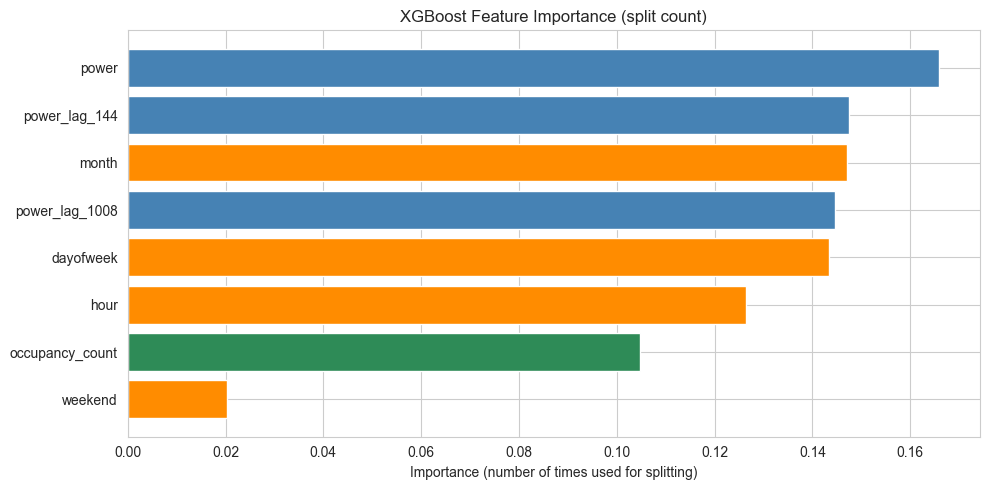

In [16]:
final_model_weight = XGBRegressor(**best_params, random_state=42, tree_method="hist",
                                   verbosity=0, importance_type="weight")
final_model_weight.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": final_model_weight.feature_importances_,
}).sort_values("importance", ascending=True)

lag_features = {"power", "power_lag_144", "power_lag_1008"}
calendar_features = {"hour", "dayofweek", "month", "weekend"}

def color_for(feat):
    if feat in lag_features:
        return "steelblue"
    elif feat in calendar_features:
        return "darkorange"
    else:                                   # occupancy_count
        return "seagreen"

colors = [color_for(f) for f in importance_df["feature"]]

plt.figure(figsize=(10, 5))
plt.barh(importance_df["feature"], importance_df["importance"], color=colors)
plt.title("XGBoost Feature Importance (split count)")
plt.xlabel("Importance (number of times used for splitting)")
plt.tight_layout()
plt.show()

# ── Log feature importance to TensorBoard ──────────────────────────────────
tb.log_feature_importance(
    feature_names=FEATURES,
    importances=final_model.feature_importances_,
    top_n=len(FEATURES)
)


In [17]:
importance_df.sort_values("importance", ascending=False)

,feature,importance
0,power,0.165953
6,power_lag_144,0.147392
4,month,0.147062
7,power_lag_1008,0.144646
3,dayofweek,0.143438
2,hour,0.126414
1,occupancy_count,0.104778
5,weekend,0.020319


## 13. Visualisations

Same three views as the LightGBM notebook: a zoomed-in time series, a full-test scatter plot, and
a residual histogram — using `y_pred_xgb` in place of `y_pred_lgb`.

### 13.1 Actual vs. Predicted — first 1,000 test rows

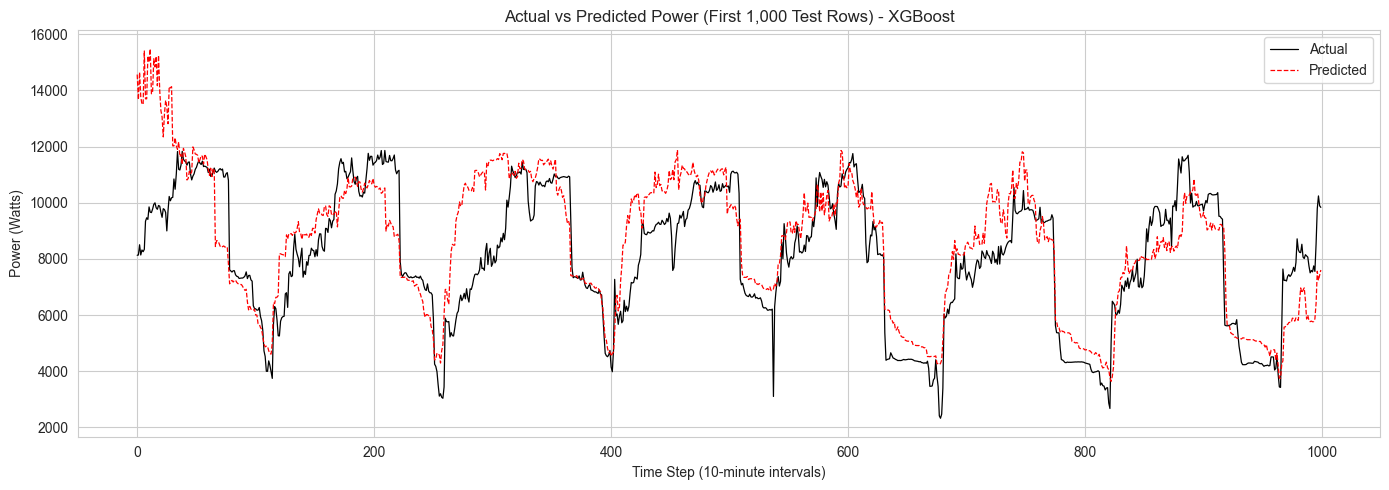

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:1000], label="Actual", color="black", linewidth=0.9)
plt.plot(y_pred_xgb[:1000], label="Predicted", color="red", linestyle="--", linewidth=0.9)
plt.title("Actual vs Predicted Power (First 1,000 Test Rows) - XGBoost")
plt.xlabel("Time Step (10-minute intervals)")
plt.ylabel("Power (Watts)")
plt.legend()
plt.tight_layout()
plt.show()

### 13.2 Actual vs. Predicted — full test set (scatter)

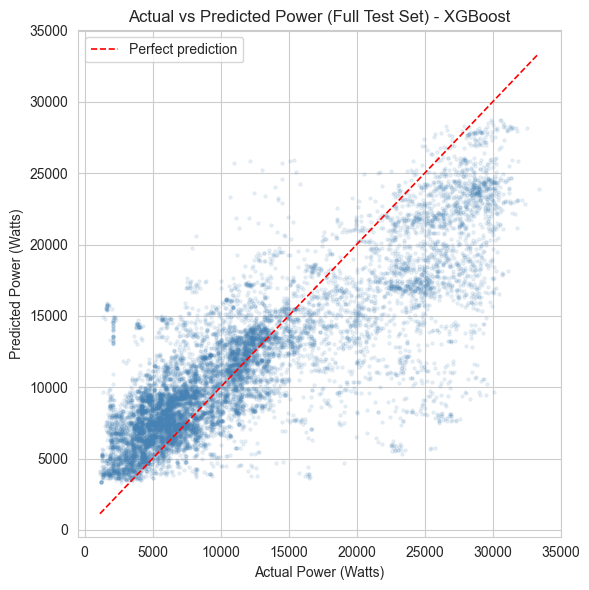

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.1, s=5, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=1.2, label="Perfect prediction")
plt.title("Actual vs Predicted Power (Full Test Set) - XGBoost")
plt.xlabel("Actual Power (Watts)")
plt.ylabel("Predicted Power (Watts)")
plt.legend()
plt.tight_layout()
plt.show()

### 13.3 Residual histogram

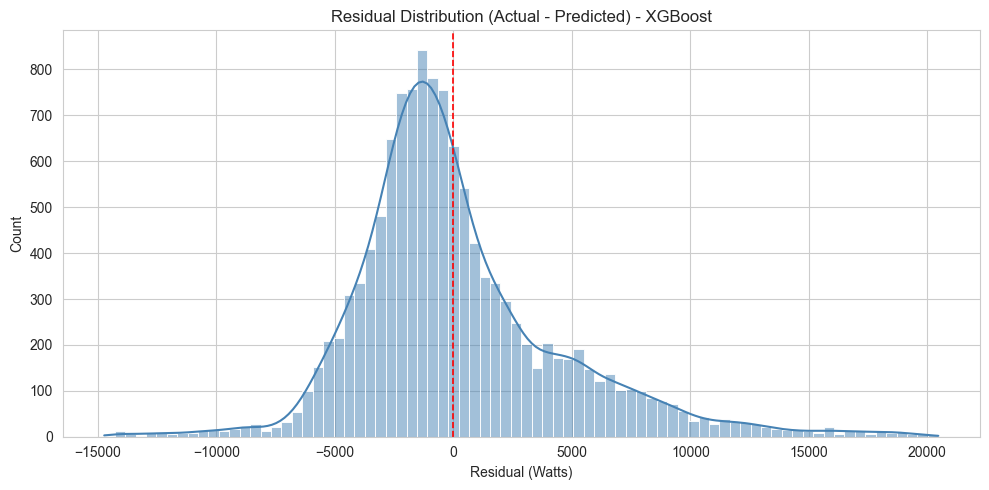

Mean residual: 165.83
Std residual:  4402.36


In [20]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=80, kde=True, color="steelblue")
plt.axvline(0, color="red", linestyle="--", linewidth=1.2)
plt.title("Residual Distribution (Actual - Predicted) - XGBoost")
plt.xlabel("Residual (Watts)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std residual:  {residuals.std():.2f}")

## 14. Limitations

Same structural limitations as the LightGBM and Extra Trees notebooks, since they come from the
data rather than the model:

1. **No weather data** — temperature is a major driver of HVAC load and isn't available here.
2. **No holiday calendar** — the model can't distinguish holidays/breaks from regular weekdays.
3. **Static model** — trained once; consumption patterns may drift over time without retraining.
4. **Sensor gaps** — 1,124 gaps >10 minutes found. Gap-aware engineering prevents corruption, but
   rows near a gap still carry less complete history.
5. **24-hour horizon only** — a full next-24-hours trajectory would need recursive/multi-output
   forecasting, which is outside this notebook's scope.
6. **Search coverage** — the hyperparameter grid has roughly 44,000 possible combinations;
   `n_iter=20` samples well under 0.1% of it, so the selected parameters are a reasonable find,
   not a proven optimum — the same caveat that applies to the LightGBM and Extra Trees searches.

## 15. Conclusion

This notebook reproduces the LightGBM notebook's exact data pipeline — features, target,
gap-aware lags, chronological split, and both baselines — and swaps in `XGBRegressor` as the
model, tuned via the same `RandomizedSearchCV`/`TimeSeriesSplit` scheme and the same
no-early-stopping final-fit approach validated on the LightGBM notebook. The MAE/RMSE/R² table in
Section 11 is directly comparable against the LightGBM and Extra Trees notebooks' results, since
every upstream step is identical; differences in final performance reflect the three model
families themselves (gradient-boosted trees via a leaf-wise/histogram learner, gradient-boosted
trees via XGBoost's depth-wise/histogram learner, and an extremely randomized forest), not
differences in data handling.

In [ ]:
# ── Log prediction plots and close TensorBoard writer ──────────────────────
tb.log_prediction_plots(y_test=y_test.values, y_pred=y_pred_xgb, n_plot=500)
tb.log_scatter_plot(y_test=y_test.values, y_pred=y_pred_xgb)
tb.close()
print('TensorBoard logging complete for XGBoost. View with: tensorboard --logdir=../runs/')